In [1]:
import numpy as np
import pandas as p
import matplotlib.pyplot as plt

##Question 1
1. Consider logistic regression with two features x1 and x2. Suppose θ0 = −6, θ1 = 1, θ2=0.

a. Write logistic regression equation for the hypothesis.

b. Write equation for decision boundary.

c. Make a graph showing decision boundary and clearly specifying the y = 0 and y = 1 regions.

##part (a) Write logistic regression equation for the hypothesis.

In [2]:
theta0 = -6
theta1 = 1
theta2 = 0
def q1_h(x1,x2):
  z = theta0 + theta1*x1 + theta2*x2
  return 1/(1+np.exp(-z))


In [3]:
# Decision boundary occurs when z = 0
# theta0 + theta1*x1 + theta2*x2 = 0

print("Decision Boundary Equation:")
print("-6 + x1 + 0*x2 = 0")
print("x1 = 6")
print()

Decision Boundary Equation:
-6 + x1 + 0*x2 = 0
x1 = 6



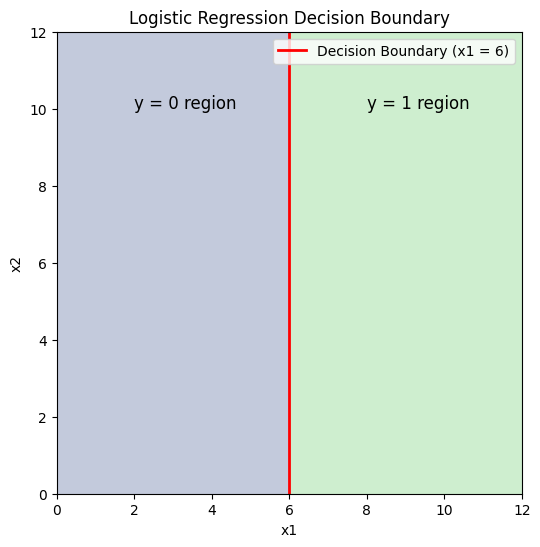

In [4]:
x1_vals = np.linspace(0, 12, 200)
x2_vals = np.linspace(0, 12, 200)

X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = q1_h(X1, X2)

plt.figure(figsize=(6,6))

plt.contourf(X1, X2, Z >= 0.5, alpha=0.3)
plt.axvline(x=6, color='red', linewidth=2, label="Decision Boundary (x1 = 6)")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Logistic Regression Decision Boundary")

plt.text(2,10,"y = 0 region",fontsize=12)
plt.text(8,10,"y = 1 region",fontsize=12)

plt.legend()
plt.show()

##Question 2
Repeat problem 1 taking θ0 = 2, θ1 = 1, θ2 = −2.

In [5]:
theta0 = 2
theta1 = 1
theta2 = -2

In [6]:
print("\nDecision Boundary:")
print("2 + x1 - 2x2 = 0")
print("x2 = 0.5*x1 + 1")


Decision Boundary:
2 + x1 - 2x2 = 0
x2 = 0.5*x1 + 1


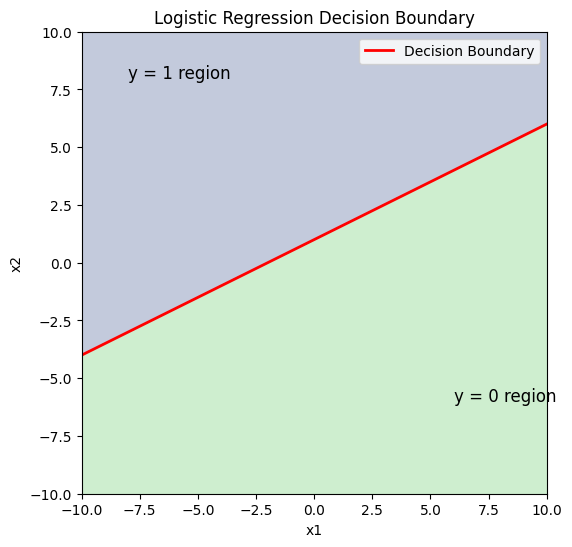

In [7]:

x1_vals = np.linspace(-10,10,200)
x2_vals = np.linspace(-10,10,200)

X1, X2 = np.meshgrid(x1_vals, x2_vals)
def q1_h(x1,x2):
  z = theta0 + theta1*x1 + theta2*x2
  return 1/(1+np.exp(-z))

Z = q1_h(X1, X2)

plt.figure(figsize=(6,6))

plt.contourf(X1, X2, Z >= 0.5, alpha=0.3)

x1_line = np.linspace(-10,10,200)
x2_line = 0.5*x1_line + 1
plt.plot(x1_line, x2_line, color='red', linewidth=2, label="Decision Boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Logistic Regression Decision Boundary")

plt.text(-8,8,"y = 1 region",fontsize=12)
plt.text(6,-6,"y = 0 region",fontsize=12)

plt.legend()
plt.show()

##Question 3
3. The following table shows average temperature values and their corresponding average humidity values for 12 months
of a year for a certain city. We intend to design a prediction system for humidity using temperature values as feature.
Feature
Temperature (0C)

14.1 16.7 19.7 25.2 25.1 18.8 11.7 10.2 9.0 9.1 10.5 12.6

Target
Humidity (%)

44.3 50.4 46.8 33.7 37.4 54.2 68.2 69.0 45.0 51.3 20.7 24.4

[You can do the calculations manually or may use excel for ease]

a. Add an output IsHumid which is 1 if humidity > 55%.

b. Write logistic regression equation for the output IsHumid.

c. Find the equation for decision boundary.

d. Find predicted probability values h(x
(i)
), if θ0 = 1.366 and θ1 = −0.115.


e. Find predicted output (0 or 1), setting threshold to 0.5.

f. Formulate the resulting confusion matrix.

g. Find accuracy, precision, recall and f1_score.

In [8]:
from sklearn.metrics import confusion_matrix

In [9]:
temperature = np.array([14.1,16.7,19.7,25.2,25.1,18.8,11.7,10.2,9.0,9.1,10.5,12.6])
humidity = np.array([44.3,50.4,46.8,33.7,37.4,54.2,68.2,69.0,45.0,51.3,20.7,24.4])

In [10]:
temp_humi = p.DataFrame({
    "Temperature": temperature,
    "Humidity": humidity
})

##part (a) Add an output IsHumid which is 1 if humidity > 55%.

In [11]:
temp_humi['isHumid'] = np.where(temp_humi['Humidity'] > 55, 1, 0)
temp_humi

,Temperature,Humidity,isHumid
0,14.1,44.3,0
1,16.7,50.4,0
2,19.7,46.8,0
3,25.2,33.7,0
4,25.1,37.4,0
5,18.8,54.2,0
6,11.7,68.2,1
7,10.2,69.0,1
8,9.0,45.0,0
9,9.1,51.3,0


##b. Write logistic regression equation for the output IsHumid.

In [12]:
theta0 = 1.366
theta1 = -0.115

def temp_humi_h(temp):
  z = theta0 + theta1*temp
  return 1/(1+np.exp(-z))

##c. Find the equation for decision boundary.

In [13]:
print("Decision Boundary Equation:")
print("1.366 - 0.115*temp = 0")
decision_boundary = -theta0/theta1
print("decision boundary equation : temp = ", decision_boundary)


Decision Boundary Equation:
1.366 - 0.115*temp = 0
decision boundary equation : temp =  11.878260869565217


##own work : plotting for visualization

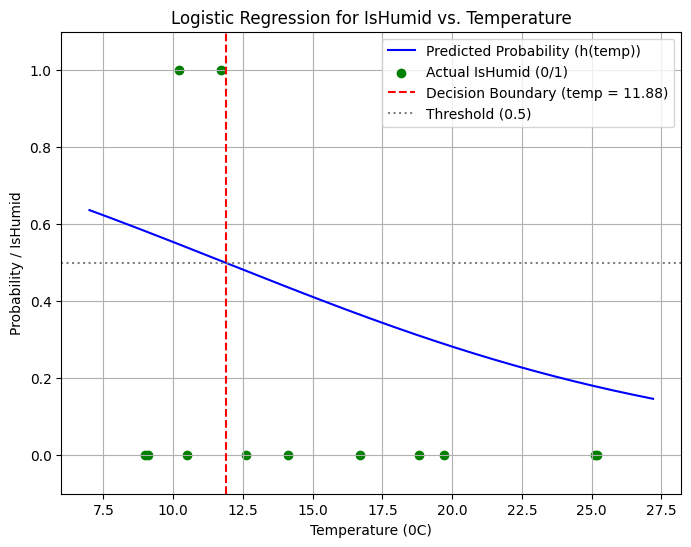

In [14]:
import matplotlib.pyplot as plt

# Get temperature values and actual 'isHumid' values
temp_values = temp_humi['Temperature'].values
actual_isHumid = temp_humi['isHumid'].values

# Calculate predicted probabilities
predicted_probs = temp_humi_h(temp_values)

plt.figure(figsize=(8, 6))

# Plot the predicted probabilities (logistic curve)
temp_range = np.linspace(temp_values.min() - 2, temp_values.max() + 2, 200)
prob_curve = temp_humi_h(temp_range)
plt.plot(temp_range, prob_curve, color='blue', label='Predicted Probability (h(temp))')

# Plot the actual 'isHumid' values
plt.scatter(temp_values, actual_isHumid, color='green', marker='o', label='Actual IsHumid (0/1)')

# Plot the decision boundary
decision_boundary = -theta0 / theta1
plt.axvline(x=decision_boundary, color='red', linestyle='--', label=f'Decision Boundary (temp = {decision_boundary:.2f})')

# Plot the threshold line at 0.5
plt.axhline(y=0.5, color='gray', linestyle=':', label='Threshold (0.5)')

plt.xlabel("Temperature (0C)")
plt.ylabel("Probability / IsHumid")
plt.title("Logistic Regression for IsHumid vs. Temperature")
plt.ylim(-0.1, 1.1) # Ensure y-axis covers 0 to 1
plt.grid(True)
plt.legend()
plt.show()

##d. Find predicted probability values h(x (i) ), if θ0 = 1.366 and θ1 = −0.115.

In [15]:
predicted_probs = temp_humi_h(temp_values)
print("Predicted Probabilities:")
for temp, prob,ishum in zip(temp_values, predicted_probs,temp_humi['isHumid']):
    print(f"Temperature: {temp:.1f}C, Predicted Probability: {prob:.4f}, isHumid : {ishum}")

Predicted Probabilities:
Temperature: 14.1C, Predicted Probability: 0.4365, isHumid : 0
Temperature: 16.7C, Predicted Probability: 0.3648, isHumid : 0
Temperature: 19.7C, Predicted Probability: 0.2892, isHumid : 0
Temperature: 25.2C, Predicted Probability: 0.1777, isHumid : 0
Temperature: 25.1C, Predicted Probability: 0.1794, isHumid : 0
Temperature: 18.8C, Predicted Probability: 0.3109, isHumid : 0
Temperature: 11.7C, Predicted Probability: 0.5051, isHumid : 1
Temperature: 10.2C, Predicted Probability: 0.5481, isHumid : 1
Temperature: 9.0C, Predicted Probability: 0.5820, isHumid : 0
Temperature: 9.1C, Predicted Probability: 0.5792, isHumid : 0
Temperature: 10.5C, Predicted Probability: 0.5395, isHumid : 0
Temperature: 12.6C, Predicted Probability: 0.4793, isHumid : 0


observation : the predicted probability at some places is greter than 0.5 but the isHumid value not 1

##e. Find predicted output (0 or 1), setting threshold to 0.5.

In [16]:
Predicted_Class= np.where(predicted_probs >= 0.5,1,0)

print("\nPredicted Classes:\n")
for temp, prob,ishum in zip(temp_values,temp_humi['isHumid'],Predicted_Class):
    print(f"Temperature: {temp:.1f}C, isHumid : {ishum},Predicted class: {prob},")


Predicted Classes:

Temperature: 14.1C, isHumid : 0,Predicted class: 0,
Temperature: 16.7C, isHumid : 0,Predicted class: 0,
Temperature: 19.7C, isHumid : 0,Predicted class: 0,
Temperature: 25.2C, isHumid : 0,Predicted class: 0,
Temperature: 25.1C, isHumid : 0,Predicted class: 0,
Temperature: 18.8C, isHumid : 0,Predicted class: 0,
Temperature: 11.7C, isHumid : 1,Predicted class: 1,
Temperature: 10.2C, isHumid : 1,Predicted class: 1,
Temperature: 9.0C, isHumid : 1,Predicted class: 0,
Temperature: 9.1C, isHumid : 1,Predicted class: 0,
Temperature: 10.5C, isHumid : 1,Predicted class: 0,
Temperature: 12.6C, isHumid : 0,Predicted class: 0,


##f. Formulate the resultant confusion matrix

In [17]:
cm = confusion_matrix(temp_humi["isHumid"], Predicted_Class)

print("\nConfusion Matrix:")
print(cm)

TN, FP, FN, TP = cm.ravel()
print("True Positive",TP)
print("True Negative",TN)
print("False Positive",FP)
print("False Negative",FN)



Confusion Matrix:
[[7 3]
 [0 2]]
True Positive 2
True Negative 7
False Positive 3
False Negative 0


g. Find accuracy, precision, recall and f1_score.

In [18]:
accuracy = (TP+TN)/(TP+TN+FP+FN)
precision = TP/(TP+FP) if (TP+FP)!=0 else 0
recall = TP/(TP+FN) if (TP+FN)!=0 else 0
f1 = 2*(precision*recall)/(precision+recall) if (precision+recall)!=0 else 0

print("\nAccuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)


Accuracy: 0.75
Precision: 0.4
Recall: 1.0
F1 Score: 0.5714285714285715


5. Following figure shows six pies that Johnny likes, and six that he does not.

 Some possible attributes could be shape, crust size, crust shade, filling size, and filling shape.
 Number of classes or labels: 2, either Johnny like the pie or he does not.
 Considering only 3 features pie shape, crust size and filling size, the following table represents Jonny’s choice of
pies.

Training
Example Shape Crust Size Filling Size Choice
1 Circle Thick Thick positive
2 Circle Thick Thick positive
3 Triangle Thick Thick positive
4 Circle Thin Thin positive
5 Square Thick Thin positive
6 Circle Thick Thin positive
7 Circle Thick Thick negative
8 Square Thick Thick negative
9 Triangle Thin Thin negative
10 Circle Thick Thick negative
11 Square Thick Thick negative
12 Triangle Thick Thick negative

a. Write logistic regression equation for the output Choice.

b. Encode all the categorical features using some appropriate coding method.

c. Implement the model in Python and provide the following:

 List the value for all parameters.

 Formulate the resulting confusion matrix.

 Find accuracy, precision, recall and f1_score.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

##b. Encode all the categorical features using some appropriate coding method.

In [20]:
data = {
    "Shape": ["Circle","Circle","Triangle","Circle","Square","Circle",
              "Circle","Square","Triangle","Circle","Square","Triangle"],

    "Crust_Size": ["Thick","Thick","Thick","Thin","Thick","Thick",
                   "Thick","Thick","Thin","Thick","Thick","Thick"],

    "Filling_Size": ["Thick","Thick","Thick","Thin","Thin","Thin",
                     "Thick","Thick","Thin","Thick","Thick","Thick"],

    "Choice": ["positive","positive","positive","positive","positive","positive",
               "negative","negative","negative","negative","negative","negative"]
}

In [22]:
df = p.DataFrame(data)

In [23]:
df["Shape"] = df["Shape"].map({"Circle":0, "Square":1, "Triangle":2})
df["Crust_Size"] = df["Crust_Size"].map({"Thin":0, "Thick":1})
df["Filling_Size"] = df["Filling_Size"].map({"Thin":0, "Thick":1})
df["Choice"] = df["Choice"].map({"negative":0, "positive":1})

print("Encoded Dataset:\n", df)


Encoded Dataset:
     Shape  Crust_Size  Filling_Size  Choice
0       0           1             1       1
1       0           1             1       1
2       2           1             1       1
3       0           0             0       1
4       1           1             0       1
5       0           1             0       1
6       0           1             1       0
7       1           1             1       0
8       2           0             0       0
9       0           1             1       0
10      1           1             1       0
11      2           1             1       0


In [27]:
X=df[['Shape','Crust_Size','Filling_Size']]
Y=df['Choice']


In [28]:
model_q5 = LogisticRegression()
model_q5.fit(X,Y)


LogisticRegression()

##a. Write logistic regression equation for the output Choice.

In [29]:
intercept = model_q5.intercept_[0]
coefficients = model_q5.coef_[0]

print("\nLogistic Regression Parameters")
print("Intercept (θ0):", intercept)
print("θ1 (Shape):", coefficients[0])
print("θ2 (Crust_Size):", coefficients[1])
print("θ3 (Filling_Size):", coefficients[2])

print("\nLogistic Regression Equation:")
print(f"P(Choice=1) = 1 / (1 + e^-( {intercept} + {coefficients[0]}*Shape + {coefficients[1]}*Crust_Size + {coefficients[2]}*Filling_Size ))")

# -----------------------------
# Predictions
# -----------------------------

y_pred = model_q5.predict(X)


Logistic Regression Parameters
Intercept (θ0): 0.7110447158128492
θ1 (Shape): -0.49916373255382973
θ2 (Crust_Size): 0.0992617259236775
θ3 (Filling_Size): -0.6314386805201213

Logistic Regression Equation:
P(Choice=1) = 1 / (1 + e^-( 0.7110447158128492 + -0.49916373255382973*Shape + 0.0992617259236775*Crust_Size + -0.6314386805201213*Filling_Size ))


intercept_: The underscore (_) at the end of intercept_ (and coef_) is a scikit-learn convention. It signifies that these attributes are learned parameters that are available only after the model has been trained using the fit() method. Before fit() is called, intercept_ would not exist.

[0]: The LogisticRegression model can handle both binary (two-class) and multi-class classification problems. For multi-class problems, intercept_ would be an array where each element represents the intercept for a specific class. In your case, it's a binary classification (positive/negative), so there's only one intercept, which is why we access the first (and only) element using [0].

In [30]:
y_pred

array([1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0])

In [31]:
cm = confusion_matrix(Y, y_pred)
print("\nConfusion Matrix:\n", cm)

# -----------------------------
# Performance Metrics
# -----------------------------

accuracy = accuracy_score(Y, y_pred)
precision = precision_score(Y, y_pred)
recall = recall_score(Y, y_pred)
f1 = f1_score(Y, y_pred)

print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Confusion Matrix:
 [[4 2]
 [1 5]]

Accuracy: 0.75
Precision: 0.7142857142857143
Recall: 0.8333333333333334
F1 Score: 0.7692307692307693


In [41]:
fish_df = p.read_csv("Dataset_Fish_Market.csv")

In [43]:
fish_df['Species'], unique_species = p.factorize(fish_df['Species'])
print("Species mapping:")
for i, species_name in enumerate(unique_species):
    print(f"{species_name}: {i}")

Species mapping:
Bream: 0
Roach: 1
Whitefish: 2
Parkki: 3
Perch: 4
Pike: 5
Smelt: 6


In [44]:
fish_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    int64  
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 8.8 KB


In [46]:
x = fish_df.drop('Species', axis=1)
y = fish_df['Species']

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [52]:
model_q6 = LogisticRegression(max_iter=1000)
model_q6.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [54]:
print("Intercepts:")
print(model_q6.intercept_)

print("\nCoefficients:")
print(model_q6.coef_)

print("\nClasses:")
print(model_q6.classes_)

Intercepts:
[-0.66638054 -1.08637143 -0.35194833  0.41706846  2.05817716 -1.14677958
  0.77623425]

Coefficients:
[[ 2.18549282e-02 -1.10729492e+00 -9.18160631e-01  1.27295128e+00
   1.44047986e+00 -4.81621614e-01]
 [-1.47638738e-03  1.06776133e-01 -1.36280586e+00  1.27555360e+00
  -3.09924094e-02  5.67715285e-01]
 [ 1.84764387e-02 -5.11260650e-01 -1.27665798e-01  2.90590341e-01
   3.00177343e-01  6.83718567e-01]
 [ 3.98125311e-04  2.92331703e-01  8.67544362e-02 -8.41747303e-01
   2.00116362e+00 -7.48253286e-02]
 [ 1.29924083e-02  4.38593339e-01  2.04462232e+00 -2.24758097e+00
  -4.46694281e-01  6.88334596e-01]
 [ 1.75177835e-02  2.67386956e-01  1.02948995e-01  1.52508121e-01
  -1.58483089e+00 -7.36771226e-01]
 [-6.97632966e-02  5.13467443e-01  1.74306535e-01  9.77249237e-02
  -1.67930325e+00 -6.46550279e-01]]

Classes:
[0 1 2 3 4 5 6]


we have separate intercepts and separate coefficient arrays for each class

In [55]:
y_pred = model_q6.predict(X_test)

##part b

In [58]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# -----------------------------
# Performance Metrics
# -----------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Confusion Matrix:
 [[10  0  0  0  0  0  0]
 [ 0  1  0  0  0  0  0]
 [ 0  2  1  0  0  0  0]
 [ 0  0  0  1  0  0  0]
 [ 0  0  0  0  9  0  0]
 [ 0  0  0  0  0  3  0]
 [ 0  0  0  0  0  0  5]]

Accuracy: 0.9375
Precision: 0.9791666666666667
Recall: 0.9375
F1 Score: 0.9375


this confusion matrix is among al the classes from 0 till 6 on both x and y axis
